# Домашнее задание "Варианционные автоэнкодеры"

In [1]:
# Загружаю библиотеки для работы
import os
import imageio
import kagglehub
import skimage.io
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from skimage.transform import resize

from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets
from torchvision import transforms
from torch.autograd import Variable
import torch.utils.data as data_utils

%matplotlib inline

# Боюсь красных всплывающих сообщений, поэтому заблокирую их )))
import warnings
warnings.filterwarnings('ignore')

# Часть 1. Vanilla Autoencoder
## 1.1. Подготовка данных
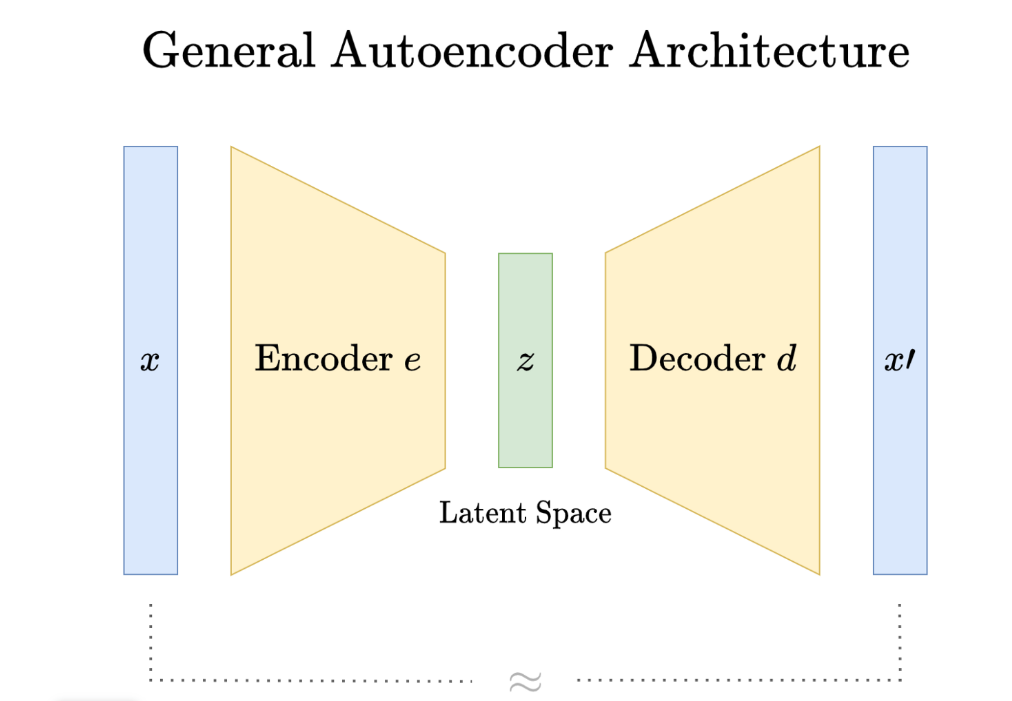

In [2]:
# Скачиваю датасет с изображениями
images_path = kagglehub.dataset_download("jessicali9530/lfw-dataset")
print("Path to dataset files:", images_path)

Path to dataset files: /kaggle/input/lfw-dataset


In [3]:
# Скачиваю атрибуты изображений
attrs_path = kagglehub.dataset_download("averkij/lfw-attributes")
print("Path to dataset files:", attrs_path)

Path to dataset files: /kaggle/input/lfw-attributes


In [4]:
# Указываю пути
DATASET_PATH ="/kaggle/input/lfw-dataset/lfw-deepfunneled/lfw-deepfunneled/"
ATTRIBUTES_PATH = "/kaggle/input/lfw-attributes/lfw_attributes.txt"

In [5]:
# Задаю функцию: для загрузки и сопоставления изображений с атрибутами, предподготовки изображений
def fetch_dataset(dx=80, dy=80, dimx=45, dimy=45):

    df_attrs = pd.read_csv(ATTRIBUTES_PATH, sep='\t', skiprows=1,)
    df_attrs = pd.DataFrame(df_attrs.iloc[:, :-1].values, columns = df_attrs.columns[1:])

    photo_ids = []
    for dirpath, dirnames, filenames in os.walk(DATASET_PATH):
        for fname in filenames:
            if fname.endswith(".jpg"):
                fpath = os.path.join(dirpath, fname)
                photo_id = fname[:-4].replace('_', ' ').split()
                person_id = ' '.join(photo_id[:-1])
                photo_number = int(photo_id[-1])
                photo_ids.append({'person': person_id,'imagenum': photo_number, 'photo_path': fpath})

    photo_ids = pd.DataFrame(photo_ids)
    df = pd.merge(df_attrs,photo_ids,on=('person', 'imagenum'))

    assert len(df) == len(df_attrs), "Потеряны данные при объединении датафреймов!"

    images = df['photo_path'].apply(imageio.imread)\
                                .apply(lambda img:img[dy:-dy, dx:-dx])\
                                .apply(lambda img: np.array(Image.fromarray(img).resize([dimx, dimy])) )

    images = np.stack(images.values).astype('uint8')
    attrs = df.drop(["photo_path","person","imagenum"],axis=1)

    return images, attrs

In [6]:
# Датасет = картинки + атрибуты
images, attrs = fetch_dataset()

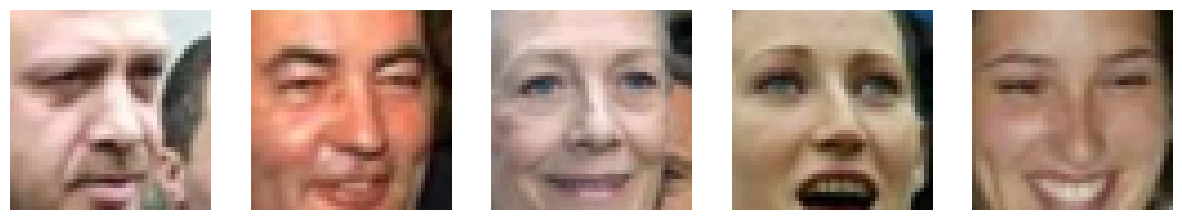

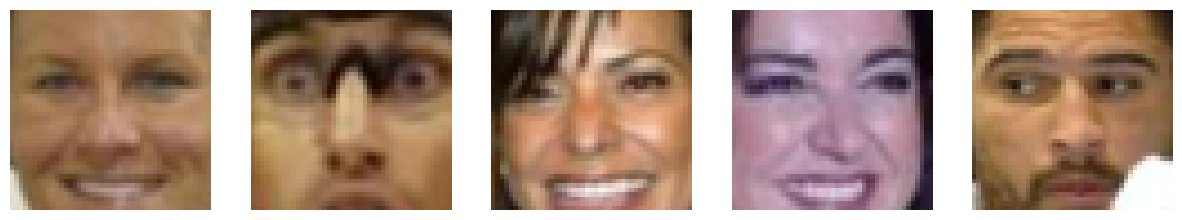

torch.Size([10514, 3, 45, 45])
torch.Size([2629, 3, 45, 45])


In [7]:
# Разделю на train и val
images_train, images_val, attrs_train, attrs_val = train_test_split(
    images, attrs, test_size=0.2, random_state=42
)

# Визуализирую несколько изображений
def show_images(images, n=5):
    plt.figure(figsize=(15, 3))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        plt.imshow(images[i])
        plt.axis('off')
    plt.show()

show_images(images_train)
show_images(images_val)

# Преобразовываю к тензорам PyTorch
transform = transforms.Compose([
    transforms.ToTensor(),  # (H, W, C) -> (C, H, W), значения в [0, 1]
])

images_train_tensors = torch.stack([transform(img) for img in images_train])
images_val_tensors = torch.stack([transform(img) for img in images_val])

print(images_train_tensors.shape)  # (N, 3, 45, 45)
print(images_val_tensors.shape)    # (N, 3, 45, 45)

## 1.2. Архитектура модели

Реализую свёрточный автоэнкодер, который хорошо работает для восстановления изображений лиц и сохраняет их структурные особенности

In [8]:
# Выберу размер латентного вектора
dim_code = 128  

class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        
        # Определю архитектуру энкодера 
        self.encoder = nn.Sequential(
            # Сверточные слои для извлечения признаков
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1),  # [batch, 32, 45, 45]
            nn.ReLU(True),
            nn.MaxPool2d(2),  # [batch, 32, 22, 22]
            
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),  # [batch, 64, 22, 22]
            nn.ReLU(True),
            nn.MaxPool2d(2),  # [batch, 64, 11, 11]
            
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),  # [batch, 128, 11, 11]
            nn.ReLU(True),
            nn.MaxPool2d(2),  # [batch, 128, 5, 5]
            
            # Преобразование в вектор
            nn.Flatten(),  # [batch, 128*5*5]
            nn.Linear(128*5*5, dim_code)  # [batch, dim_code]
        )
        
        # Определяю архитектуру декодера
        self.decoder = nn.Sequential(
            nn.Linear(dim_code, 128*5*5),  # [batch, 128*5*5]
            nn.ReLU(True),
            # Восстанавление трехмерной структуры
            nn.Unflatten(1, (128, 5, 5)),  # [batch, 128, 5, 5]
            
            # Транспонированные свертки для увеличения разрешения
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1),  # [batch, 64, 11, 11]
            nn.ReLU(True),
            
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),  # [batch, 32, 22, 22]
            nn.ReLU(True),
            
            nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1, output_padding=1),  # [batch, 3, 45, 45]
            nn.Sigmoid(),  # Нормализовывание выходных значений в диапазоне [0, 1]
            nn.Upsample(size=(45, 45), mode='bilinear', align_corners=False)
        )
    
    def forward(self, x):
        # Реализую forward проход автоэнкодера
        latent_code = self.encoder(x)
        reconstruction = self.decoder(latent_code)
        
        return reconstruction, latent_code

# Определю функцию потерь и оптимизатор
criterion = nn.MSELoss()  # среднеквадратичная ошибка для изображений
autoencoder = Autoencoder()
optimizer = optim.Adam(autoencoder.parameters(), lr=0.001)

## 1.3 Обучение

Используется устройство: cuda
Эпоха [1/50], Train Loss: 0.024759, Val Loss: 0.013291

Реконструкции после эпохи 1:


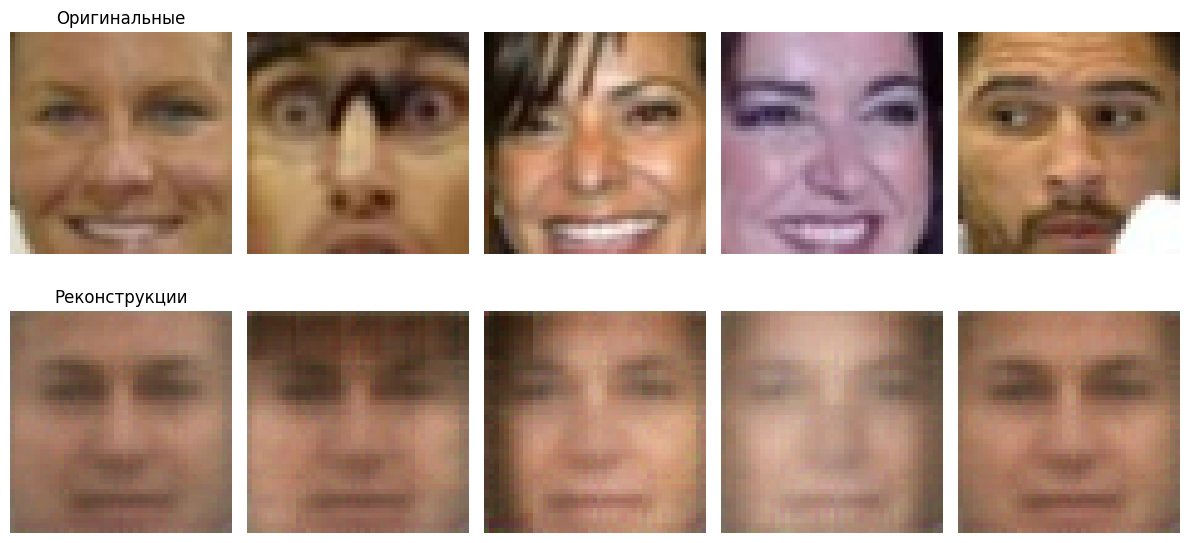

Эпоха [2/50], Train Loss: 0.009934, Val Loss: 0.008213
Эпоха [3/50], Train Loss: 0.007264, Val Loss: 0.006715
Эпоха [4/50], Train Loss: 0.006214, Val Loss: 0.005920
Эпоха [5/50], Train Loss: 0.005447, Val Loss: 0.005573
Эпоха [6/50], Train Loss: 0.004998, Val Loss: 0.005067
Эпоха [7/50], Train Loss: 0.004661, Val Loss: 0.004669
Эпоха [8/50], Train Loss: 0.004407, Val Loss: 0.004630
Эпоха [9/50], Train Loss: 0.004188, Val Loss: 0.004197
Эпоха [10/50], Train Loss: 0.003979, Val Loss: 0.004059

Реконструкции после эпохи 10:


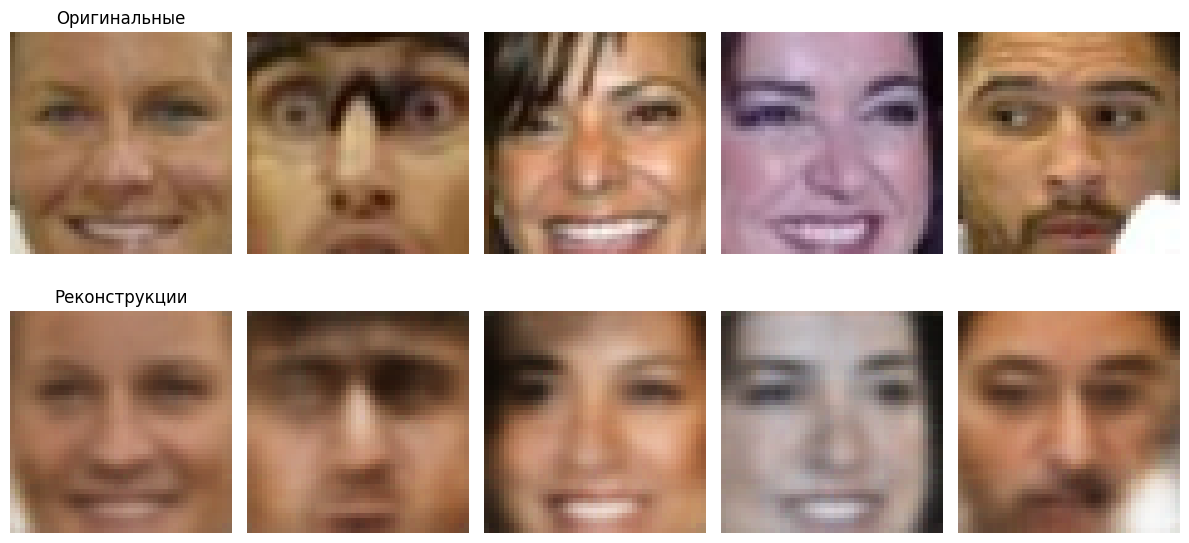

Эпоха [11/50], Train Loss: 0.003847, Val Loss: 0.004055
Эпоха [12/50], Train Loss: 0.003675, Val Loss: 0.003779
Эпоха [13/50], Train Loss: 0.003565, Val Loss: 0.003703
Эпоха [14/50], Train Loss: 0.003455, Val Loss: 0.003607
Эпоха [15/50], Train Loss: 0.003350, Val Loss: 0.003465
Эпоха [16/50], Train Loss: 0.003202, Val Loss: 0.003412
Эпоха [17/50], Train Loss: 0.003079, Val Loss: 0.003446
Эпоха [18/50], Train Loss: 0.003022, Val Loss: 0.003180
Эпоха [19/50], Train Loss: 0.002941, Val Loss: 0.003167
Эпоха [20/50], Train Loss: 0.002855, Val Loss: 0.003068

Реконструкции после эпохи 20:


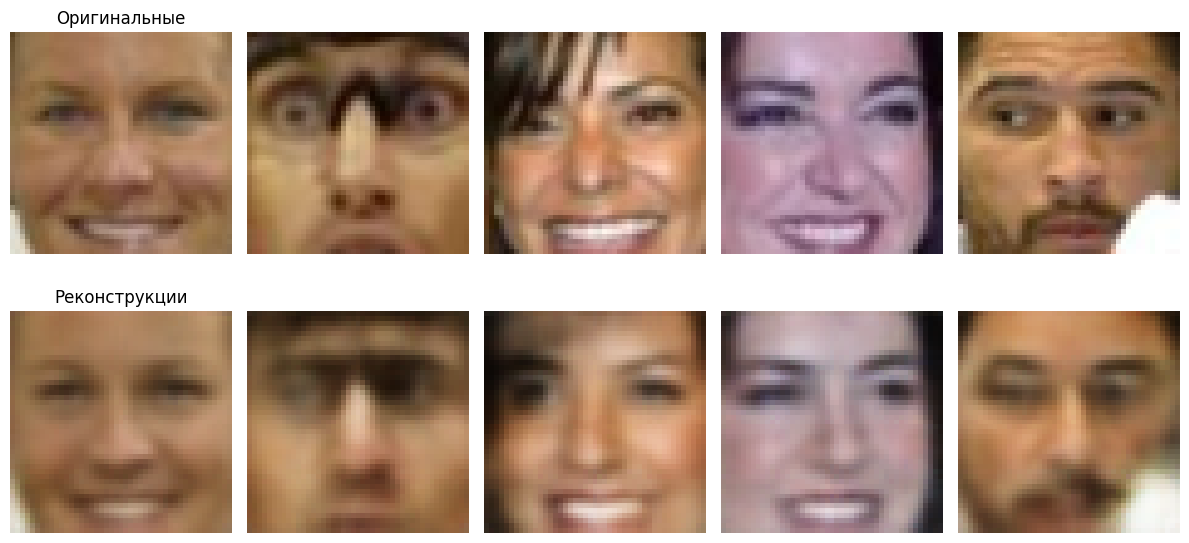

Эпоха [21/50], Train Loss: 0.002797, Val Loss: 0.003013
Эпоха [22/50], Train Loss: 0.002763, Val Loss: 0.002973
Эпоха [23/50], Train Loss: 0.002679, Val Loss: 0.002912
Эпоха [24/50], Train Loss: 0.002639, Val Loss: 0.002907
Эпоха [25/50], Train Loss: 0.002603, Val Loss: 0.002841
Эпоха [26/50], Train Loss: 0.002551, Val Loss: 0.002913
Эпоха [27/50], Train Loss: 0.002519, Val Loss: 0.002777
Эпоха [28/50], Train Loss: 0.002490, Val Loss: 0.002800
Эпоха [29/50], Train Loss: 0.002467, Val Loss: 0.002773
Эпоха [30/50], Train Loss: 0.002431, Val Loss: 0.002720

Реконструкции после эпохи 30:


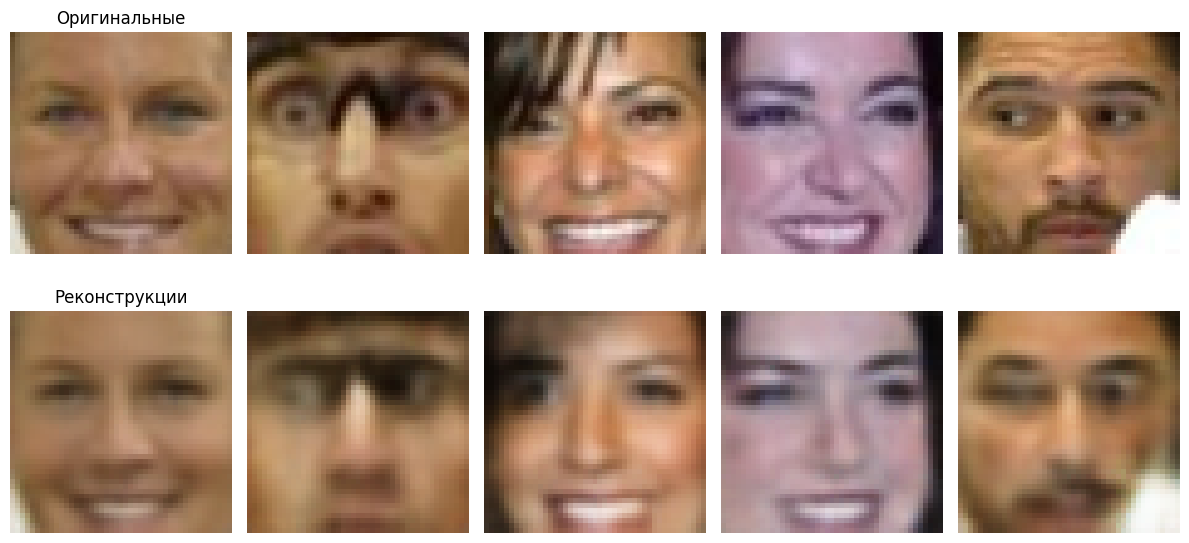

Эпоха [31/50], Train Loss: 0.002357, Val Loss: 0.002773
Эпоха [32/50], Train Loss: 0.002364, Val Loss: 0.002684
Эпоха [33/50], Train Loss: 0.002328, Val Loss: 0.002640
Эпоха [34/50], Train Loss: 0.002312, Val Loss: 0.002632
Эпоха [35/50], Train Loss: 0.002271, Val Loss: 0.002606
Эпоха [36/50], Train Loss: 0.002247, Val Loss: 0.002565
Эпоха [37/50], Train Loss: 0.002235, Val Loss: 0.002560
Эпоха [38/50], Train Loss: 0.002207, Val Loss: 0.002544
Эпоха [39/50], Train Loss: 0.002188, Val Loss: 0.002690
Эпоха [40/50], Train Loss: 0.002169, Val Loss: 0.002516

Реконструкции после эпохи 40:


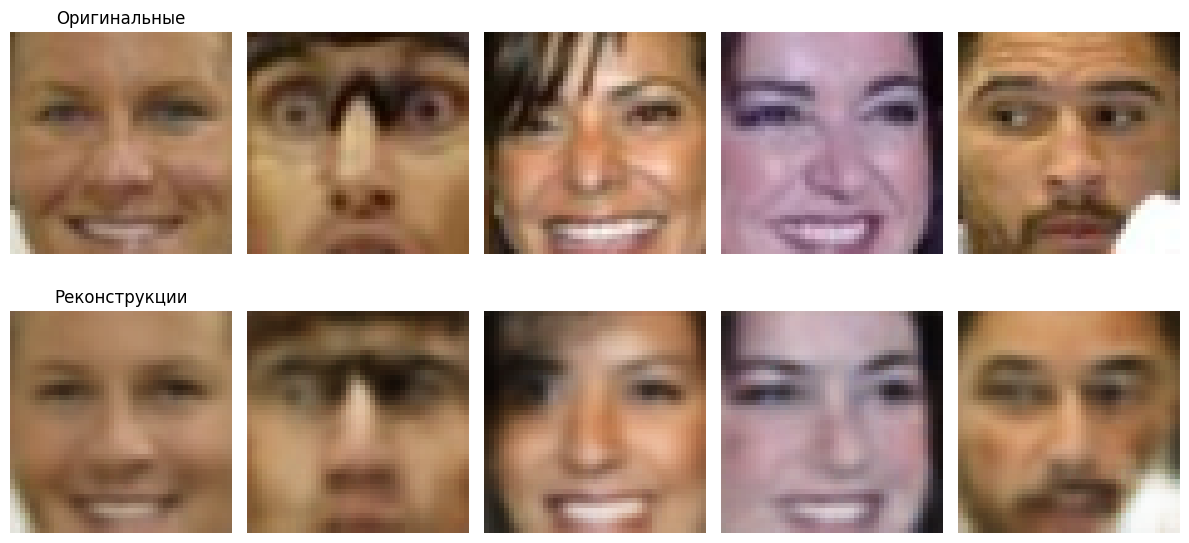

Эпоха [41/50], Train Loss: 0.002140, Val Loss: 0.002528
Эпоха [42/50], Train Loss: 0.002136, Val Loss: 0.002486
Эпоха [43/50], Train Loss: 0.002109, Val Loss: 0.002465
Эпоха [44/50], Train Loss: 0.002104, Val Loss: 0.002488
Эпоха [45/50], Train Loss: 0.002081, Val Loss: 0.002474
Эпоха [46/50], Train Loss: 0.002080, Val Loss: 0.002489
Эпоха [47/50], Train Loss: 0.002056, Val Loss: 0.003048
Эпоха [48/50], Train Loss: 0.002071, Val Loss: 0.002469
Эпоха [49/50], Train Loss: 0.002020, Val Loss: 0.002453
Эпоха [50/50], Train Loss: 0.002030, Val Loss: 0.002500

Реконструкции после эпохи 50:


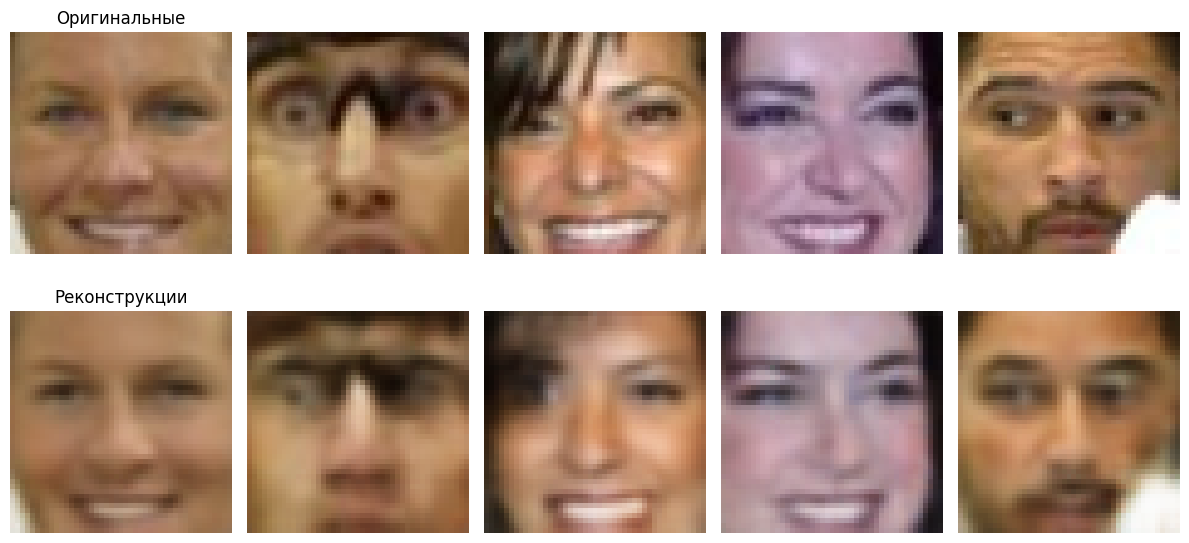

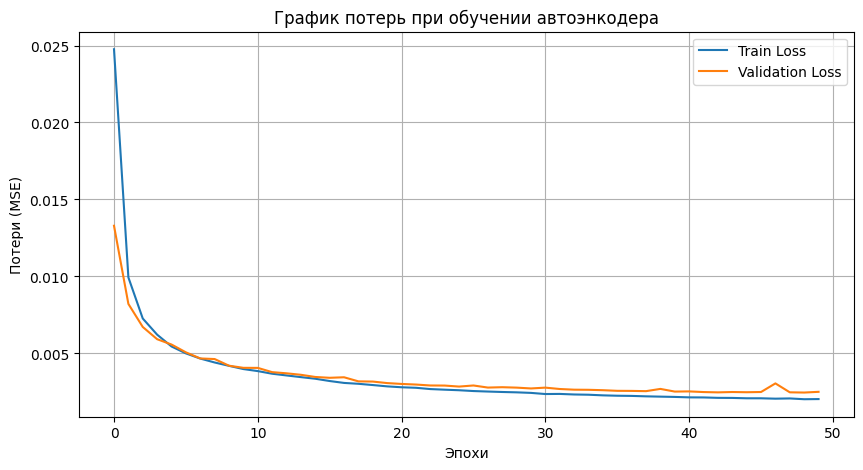


Финальные реконструкции на валидационной выборке:


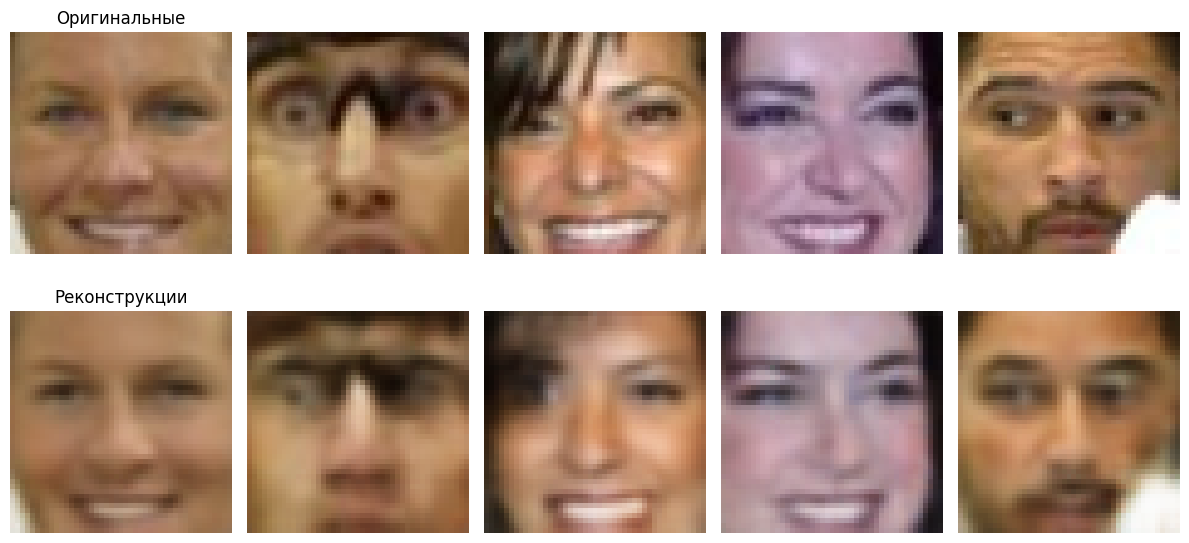

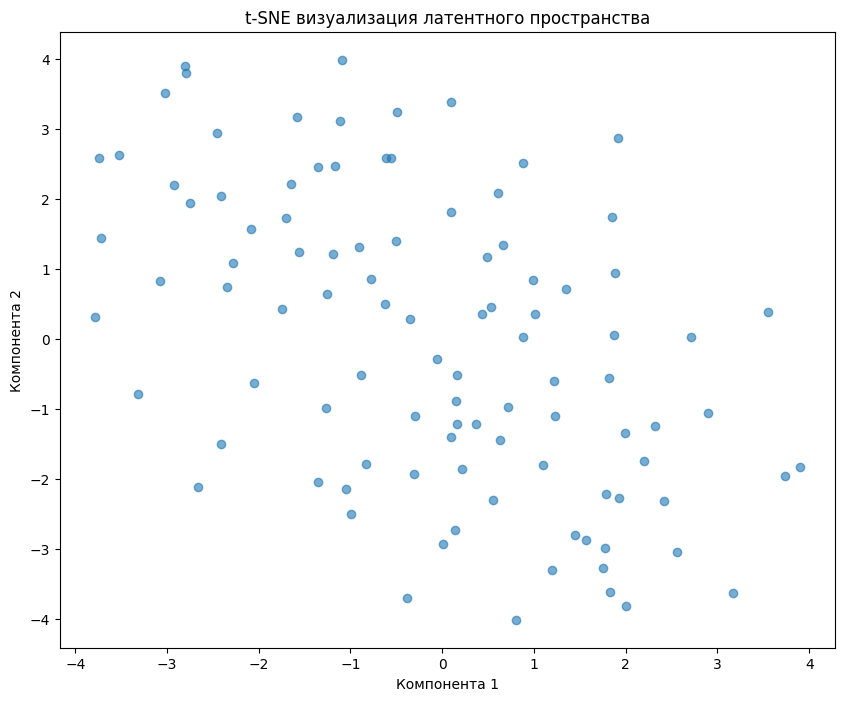

In [9]:
# Создам DataLoader для эффективной работы с данными
batch_size = 64
train_dataset = torch.utils.data.TensorDataset(images_train_tensors)
val_dataset = torch.utils.data.TensorDataset(images_val_tensors)

train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True
)
val_loader = torch.utils.data.DataLoader(
    val_dataset, batch_size=batch_size, shuffle=False
)

# Функция визуализации оригинальных и реконструированных изображений
def visualize_reconstruction(model, data_tensor, num_images=5):
    model.eval()  # переключаю модель в режим оценки
    with torch.no_grad():
        # Беру первые num_images изображений
        original = data_tensor[:num_images]
        # Получаю реконструкции
        reconstructed, _ = model(original)
        
    # Визуализирую
    plt.figure(figsize=(12, 6))
    for i in range(num_images):
        # Оригинальное изображение
        plt.subplot(2, num_images, i + 1)
        img = original[i].cpu().permute(1, 2, 0).numpy().clip(0, 1)
        plt.imshow(img)
        plt.axis('off')
        if i == 0:
            plt.title('Оригинальные')
        
        # Реконструированное изображение
        plt.subplot(2, num_images, i + 1 + num_images)
        img = reconstructed[i].cpu().permute(1, 2, 0).numpy().clip(0, 1)
        plt.imshow(img)
        plt.axis('off')
        if i == 0:
            plt.title('Реконструкции')
            
    plt.tight_layout()
    plt.show()

# Проверка работы устройства GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используется устройство: {device}")

# Перемещаем модель на устройство
autoencoder = autoencoder.to(device)

# Параметры обучения
num_epochs = 50
train_losses = []
val_losses = []

# Функция обучения модели
def train_model():
    for epoch in range(num_epochs):
        # Режим обучения
        autoencoder.train()
        train_loss = 0.0
        
        # Обучение на тренировочных данных
        for batch_idx, (data,) in enumerate(train_loader):
            data = data.to(device)
            
            # Обнуляю градиенты
            optimizer.zero_grad()
            
            # Прямой проход
            reconstructed, _ = autoencoder(data)
            
            # Вычисляю функцию потерь
            loss = criterion(reconstructed, data)
            
            # Обратное распространение ошибки
            loss.backward()
            
            # Обновляю веса
            optimizer.step()
            
            train_loss += loss.item()
            
        # Среднее значение функции потерь после эпохи
        train_loss /= len(train_loader)
        train_losses.append(train_loss)
        
        # Режим валидации
        autoencoder.eval()
        val_loss = 0.0
        
        with torch.no_grad():
            for batch_idx, (data,) in enumerate(val_loader):
                data = data.to(device)
                
                # Прямой проход
                reconstructed, _ = autoencoder(data)
                
                # Вычисляю функцию потерь
                loss = criterion(reconstructed, data)
                val_loss += loss.item()
        
        # Среднее значение функции потерь на val выборке
        val_loss /= len(val_loader)
        val_losses.append(val_loss)
        
        # Печатаю результаты текущей эпохи
        print(f'Эпоха [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}')
        
        # Визуализирую реконструкцию каждые 10 эпох
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"\nРеконструкции после эпохи {epoch+1}:")
            visualize_reconstruction(autoencoder, images_val_tensors.to(device))
            
    # Рисую график функции потерь
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.xlabel('Эпохи')
    plt.ylabel('Потери (MSE)')
    plt.title('График потерь при обучении автоэнкодера')
    plt.legend()
    plt.grid(True)
    plt.show()

# Запускаю обучение
train_model()

# Визуализирую финальные результаты
print("\nФинальные реконструкции на валидационной выборке:")
visualize_reconstruction(autoencoder, images_val_tensors.to(device), num_images=5)

# Функция для визуализации того, как закодированное пространство представляет изображения
def visualize_latent_space():
    autoencoder.eval()
    with torch.no_grad():
        # Получаю латентные векторы для изображений из val
        _, latent_vectors = autoencoder(images_val_tensors[:100].to(device))
        
        # Использую t-SNE для визуализации в 2D если латентное пространство большой размерности
        if dim_code > 2:
            from sklearn.manifold import TSNE
            tsne = TSNE(n_components=2, random_state=42)
            latent_2d = tsne.fit_transform(latent_vectors.cpu().numpy())
            
            plt.figure(figsize=(10, 8))
            plt.scatter(latent_2d[:, 0], latent_2d[:, 1], alpha=0.6)
            plt.title('t-SNE визуализация латентного пространства')
            plt.xlabel('Компонента 1')
            plt.ylabel('Компонента 2')
            plt.show()

# Визуализация латентного пространства
visualize_latent_space()

## Выводы

* 1. График потерь:

 Модель демонстрирует стабильное снижение потерь на протяжении всех 50 эпох, а кривые Train Loss и Validation Loss сходятся к значениям около 0.002, что свидетельствует о хорошей сходимости. Также Отсутствуют признаки переобучения, так как Validation Loss не растет относительно Train Loss.

* 2. Качество реконструкций:
     
Автоэнкодер успешно восстанавливает основные черты лиц (глаза, нос, рот) - общая цветовая гамма и черты лица сохраняются довольно хорошо.
Наблюдается при этом некоторая потеря детализации и небольшое размытие.

* 3. Латентное пространство:
     
t-SNE визуализация показывает относительно равномерное распределение точек без явных кластеров. Латентное представление кажется непрерывным.

## 1.4. Sampling

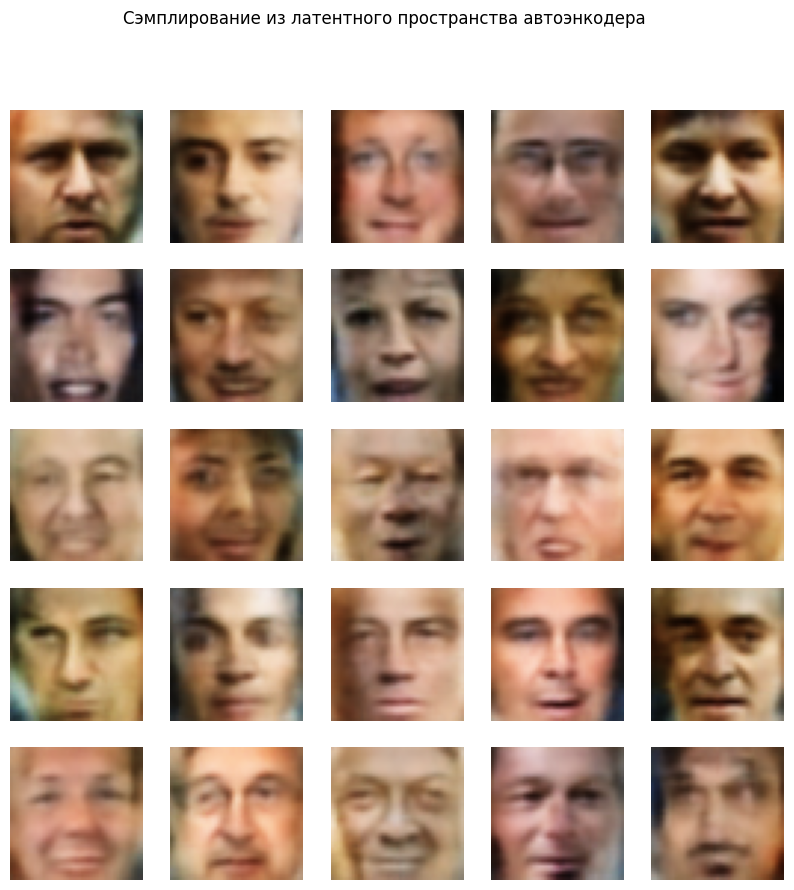

In [10]:
# Получаю латентные векторы для датасета
autoencoder.eval()
all_latents = []

with torch.no_grad():
    for batch, in train_loader:
        batch = batch.to(device)
        _, latents = autoencoder(batch)
        all_latents.append(latents.cpu().numpy())

all_latents = np.concatenate(all_latents, axis=0)

# Оцениваю параметры распределения латентного пространства
latent_mean = np.mean(all_latents, axis=0)
latent_cov = np.cov(all_latents, rowvar=False)

# Семплирую 25 новых латентных векторов из многомерного нормального распределения
num_samples = 25
z = np.random.multivariate_normal(latent_mean, latent_cov, size=num_samples)

# Преобразую к torch.Tensor и подаю в декодер
z_tensor = torch.from_numpy(z).float().to(device)
with torch.no_grad():
    generated_imgs = autoencoder.decoder(z_tensor)
    # Если нужно, меняю размер до (3, 45, 45)
    if generated_imgs.shape[-2:] != (45, 45):
        generated_imgs = torch.nn.functional.interpolate(generated_imgs, size=(45, 45), mode='bilinear', align_corners=False)

# Визуализирую сгенерированные изображения
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for i in range(num_samples):
    plt.subplot(5, 5, i + 1)
    img = generated_imgs[i].cpu().permute(1, 2, 0).numpy().clip(0, 1)
    plt.imshow(img)
    plt.axis('off')
plt.suptitle('Сэмплирование из латентного пространства автоэнкодера')
plt.show()

## 1.5 Time to make fun!

Найдено 15 улыбающихся и 15 неулыбающихся лиц


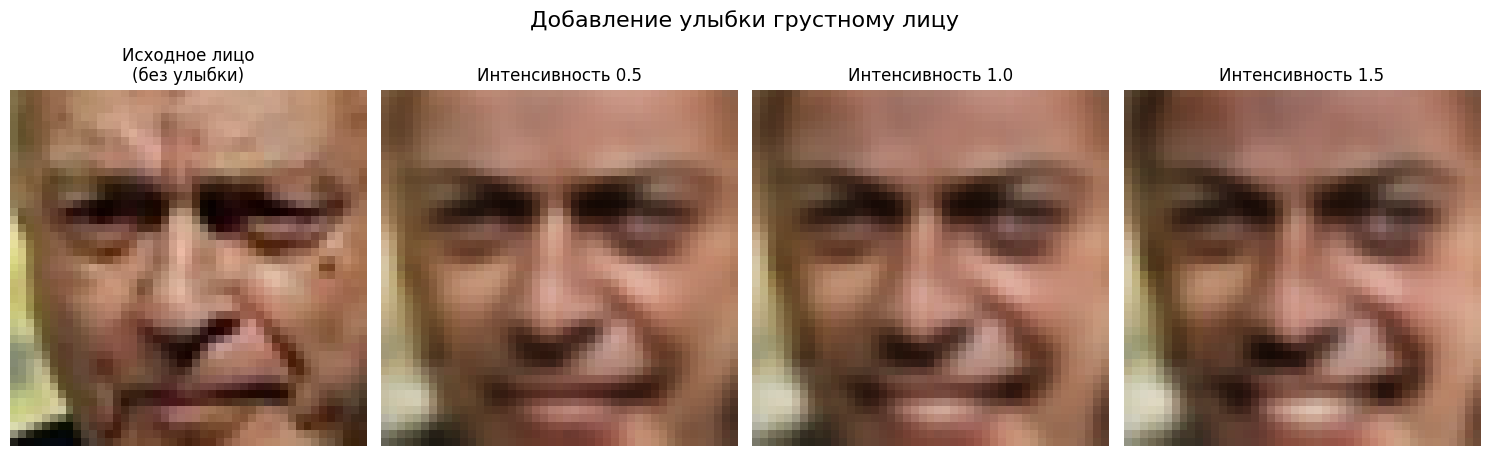

Тестовое лицо: Alfredo di Stefano, фото №1
Значение атрибута 'Smiling': -0.53


In [11]:
# Загружу данные об атрибутах
attrs_df = pd.read_csv("/kaggle/input/lfw-attributes/lfw_attributes.txt", sep='\t', skiprows=1)

# Преобразую DataFrame для удобства работы
attrs_df = pd.DataFrame(attrs_df.iloc[:, :-1].values, columns=attrs_df.columns[1:])

# Найду изображения с улыбкой и без улыбки
smiling_imgs = attrs_df[attrs_df['Smiling'] > 0.7]  # Уверенно улыбающиеся
non_smiling_imgs = attrs_df[attrs_df['Smiling'] < 0.3]  # Уверенно неулыбающиеся

# Ограничиваю до 15 изображений в каждой категории
n_samples = 15
smiling_samples = smiling_imgs.sample(n_samples, random_state=42)
non_smiling_samples = non_smiling_imgs.sample(n_samples, random_state=42)

print(f"Найдено {len(smiling_samples)} улыбающихся и {len(non_smiling_samples)} неулыбающихся лиц")

# Загружу изображения и получу их латентные представления
def load_image(person, imagenum):
    """Загружает изображение для конкретного человека и номера изображения"""
    # Формирую путь к файлу
    person_dir = person.replace(' ', '_')
    image_path = os.path.join('/kaggle/input/lfw-dataset/lfw-deepfunneled/lfw-deepfunneled', 
                             person_dir, f"{person_dir}_{imagenum:04d}.jpg")
    
    # Загружу и предобработаю изображение (как в fetch_dataset)
    img = np.array(Image.open(image_path))
    # Обрежу изображение (как в исходном коде)
    dx, dy = 80, 80
    img = img[dy:-dy, dx:-dx]
    # Изменю размер
    img = np.array(Image.fromarray(img).resize((45, 45)))
    
    # Преобразую в тензор для автоэнкодера
    img_tensor = torch.from_numpy(img.transpose(2, 0, 1)).float() / 255.0
    
    return img, img_tensor

# Получу изображения и их тензоры
smiling_images = []
smiling_tensors = []
non_smiling_images = []
non_smiling_tensors = []

for _, row in smiling_samples.iterrows():
    img, tensor = load_image(row['person'], row['imagenum'])
    smiling_images.append(img)
    smiling_tensors.append(tensor)

for _, row in non_smiling_samples.iterrows():
    img, tensor = load_image(row['person'], row['imagenum'])
    non_smiling_images.append(img)
    non_smiling_tensors.append(tensor)

smiling_tensors = torch.stack(smiling_tensors).to(device)
non_smiling_tensors = torch.stack(non_smiling_tensors).to(device)

# Вычислю латентные векторы с помощью энкодера
autoencoder.eval()
with torch.no_grad():
    # Получу латентные представления улыбающихся лиц
    _, smiling_latents = autoencoder(smiling_tensors)
    # Получу латентные представления неулыбающихся лиц
    _, non_smiling_latents = autoencoder(non_smiling_tensors)
    
    # Вычислю средние векторы
    mean_smiling_latent = torch.mean(smiling_latents, dim=0)
    mean_non_smiling_latent = torch.mean(non_smiling_latents, dim=0)
    
    # Вычислю "вектор улыбки" как разницу между средними
    smile_vector = mean_smiling_latent - mean_non_smiling_latent

# Добавлю улыбку к грустному лицу
def add_smile(face_tensor, smile_intensity=1.0):
    """Добавляет улыбку к тензору лица с заданной интенсивностью"""
    with torch.no_grad():
        # Получу латентный вектор лица
        _, latent = autoencoder(face_tensor.unsqueeze(0))
        
        # Добавлю вектор улыбки
        modified_latent = latent + smile_vector * smile_intensity
        
        # Декодирую обратно в изображение
        modified_face, _ = autoencoder.decoder(modified_latent), modified_latent
        
    return modified_face

# Выберу грустное лицо для добавления улыбки
test_index = 1
test_face = non_smiling_tensors[test_index]

# Добавлю улыбку с разной интенсивностью
modified_face_05 = add_smile(test_face, 0.5)
modified_face_10 = add_smile(test_face, 1.0)
modified_face_15 = add_smile(test_face, 1.5)

# Визуализирую результаты
plt.figure(figsize=(15, 5))

# Исходное лицо
plt.subplot(1, 4, 1)
img = test_face.cpu().permute(1, 2, 0).numpy()
plt.imshow(img)
plt.title("Исходное лицо\n(без улыбки)")
plt.axis('off')

# Лицо с добавленной улыбкой (интенсивность 0.5)
plt.subplot(1, 4, 2)
img = modified_face_05.squeeze(0).cpu().permute(1, 2, 0).numpy().clip(0, 1)
plt.imshow(img)
plt.title("Интенсивность 0.5")
plt.axis('off')

# Лицо с добавленной улыбкой (интенсивность 1.0)
plt.subplot(1, 4, 3)
img = modified_face_10.squeeze(0).cpu().permute(1, 2, 0).numpy().clip(0, 1)
plt.imshow(img)
plt.title("Интенсивность 1.0")
plt.axis('off')

# Лицо с добавленной улыбкой (интенсивность 1.5)
plt.subplot(1, 4, 4)
img = modified_face_15.squeeze(0).cpu().permute(1, 2, 0).numpy().clip(0, 1)
plt.imshow(img)
plt.title("Интенсивность 1.5")
plt.axis('off')

plt.suptitle("Добавление улыбки грустному лицу", fontsize=16)
plt.tight_layout()
plt.show()

# Выведу информацию о тестовом лице
test_person = non_smiling_samples.iloc[test_index]
print(f"Тестовое лицо: {test_person['person']}, фото №{test_person['imagenum']}")
print(f"Значение атрибута 'Smiling': {test_person['Smiling']:.2f}")

# Часть 2: Variational Autoencoder
## 2.1 Архитектура модели и обучение

In [12]:
# Загружу данные и подготовлю лоадеры
batch_size = 32
# MNIST Dataset
train_dataset = datasets.MNIST(root='./mnist_data/', train=True, transform=transforms.ToTensor(), download=True)
test_dataset = datasets.MNIST(root='./mnist_data/', train=False, transform=transforms.ToTensor(), download=False)

# Data Loader (Input Pipeline)
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:00<00:00, 41.6MB/s]


Extracting ./mnist_data/MNIST/raw/train-images-idx3-ubyte.gz to ./mnist_data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 1.12MB/s]


Extracting ./mnist_data/MNIST/raw/train-labels-idx1-ubyte.gz to ./mnist_data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:00<00:00, 10.6MB/s]


Extracting ./mnist_data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./mnist_data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 10.5MB/s]

Extracting ./mnist_data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./mnist_data/MNIST/raw



In [13]:
# Задаю архитектуру VAE
class VAE(nn.Module):
    def __init__(self):
        super(VAE, self).__init__()
        self.latent_dim = 100  # размерность латентного пространства
        
        # Энкодер
        self.encoder_fc1 = nn.Linear(784, 400)  # 784 = 28*28
        self.encoder_fc2 = nn.Linear(400, 200)
        
        # Два "хвоста" для mu и logsigma
        self.fc_mu = nn.Linear(200, self.latent_dim)
        self.fc_logsigma = nn.Linear(200, self.latent_dim)
        
        # Декодер
        self.decoder_fc1 = nn.Linear(self.latent_dim, 200)
        self.decoder_fc2 = nn.Linear(200, 400)
        self.decoder_fc3 = nn.Linear(400, 784)

    def encode(self, x):
        x = x.view(-1, 784)  # привожу изображение к вектору
        h1 = F.relu(self.encoder_fc1(x))
        h2 = F.relu(self.encoder_fc2(h1))
        
        # Получу mu и logsigma
        mu = self.fc_mu(h2)
        logsigma = self.fc_logsigma(h2)
        
        return mu, logsigma

    def gaussian_sampler(self, mu, logsigma):
        if self.training:
            # Рапараметризация: z = mu + eps * sigma
            std = torch.exp(0.5 * logsigma)
            eps = torch.randn_like(std)
            z = mu + eps * std
            return z
        else:
            # на инференсе возвращаю не случайный вектор из нормального распределения, а центральный
            return mu

    def decode(self, z):
        h3 = F.relu(self.decoder_fc1(z))
        h4 = F.relu(self.decoder_fc2(h3))
        reconstruction = torch.sigmoid(self.decoder_fc3(h4))
        reconstruction = reconstruction.view(-1, 1, 28, 28)
        
        return reconstruction

    def forward(self, x):
        mu, logsigma = self.encode(x)
        z = self.gaussian_sampler(mu, logsigma)
        reconstruction = self.decode(z)
        
        return mu, logsigma, reconstruction

In [14]:
def KL_divergence(mu, logsigma):
    """
    часть функции потерь, которая отвечает за "близость" латентных представлений разных людей
    """
    # KL = -0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)
    loss = -0.5 * torch.sum(1 + logsigma - mu.pow(2) - logsigma.exp(), dim=1)
    return loss.mean()

def log_likelihood(x, reconstruction):
    """
    часть функции потерь, которая отвечает за качество реконструкции (как mse в обычном autoencoder)
    """
    x = x.view(-1, 784)  # Привожу к векторам
    reconstruction = reconstruction.view(-1, 784)
    loss = F.binary_cross_entropy(reconstruction, x, reduction='sum')
    return loss / x.size(0)  # Среднее значение по батчу

def loss_vae(x, mu, logsigma, reconstruction):
    # VAE loss = KL divergence + reconstruction loss
    return KL_divergence(mu, logsigma) + log_likelihood(x, reconstruction)

In [15]:
criterion = loss_vae

autoencoder = VAE()

optimizer = torch.optim.Adam(autoencoder.parameters(), lr=0.001)

In [16]:
# Обучаю модель
num_epochs = 20
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
autoencoder = autoencoder.to(device)

for epoch in range(num_epochs):
    train_loss = 0
    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device)
        optimizer.zero_grad()
        
        mu, logsigma, reconstruction = autoencoder(data)
        loss = criterion(data, mu, logsigma, reconstruction)
        
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        
    # Среднее значение loss за эпоху
    train_loss /= len(train_loader.dataset)
    print(f'Эпоха {epoch+1}/{num_epochs}, Потери: {train_loss:.4f}')

Эпоха 1/20, Потери: 4.9907
Эпоха 2/20, Потери: 3.8411
Эпоха 3/20, Потери: 3.6134
Эпоха 4/20, Потери: 3.5048
Эпоха 5/20, Потери: 3.4346
Эпоха 6/20, Потери: 3.3921
Эпоха 7/20, Потери: 3.3626
Эпоха 8/20, Потери: 3.3392
Эпоха 9/20, Потери: 3.3215
Эпоха 10/20, Потери: 3.3049
Эпоха 11/20, Потери: 3.2945
Эпоха 12/20, Потери: 3.2835
Эпоха 13/20, Потери: 3.2729
Эпоха 14/20, Потери: 3.2627
Эпоха 15/20, Потери: 3.2567
Эпоха 16/20, Потери: 3.2498
Эпоха 17/20, Потери: 3.2430
Эпоха 18/20, Потери: 3.2370
Эпоха 19/20, Потери: 3.2323
Эпоха 20/20, Потери: 3.2276


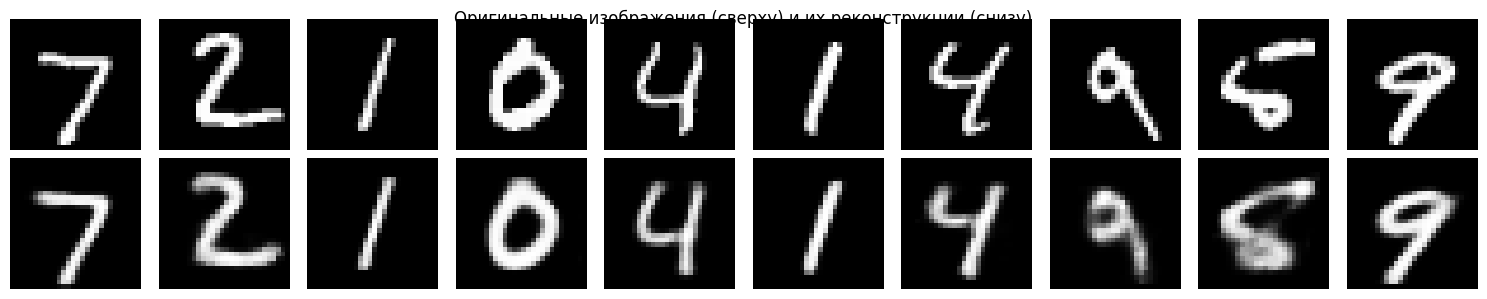

In [17]:
# Визуализирую результаты
autoencoder.eval()
with torch.no_grad():
    # Беру первые изображения из тестового датасета
    data_sample, _ = next(iter(test_loader))
    data_sample = data_sample[:10].to(device)
    
    mu, logsigma, reconstruction = autoencoder(data_sample)
    
    # Визуализирую оригиналы и реконструкции
    plt.figure(figsize=(15, 3))
    for i in range(10):
        # Оригинальное изображение
        plt.subplot(2, 10, i+1)
        plt.imshow(data_sample[i].cpu().squeeze(), cmap='gray')
        plt.axis('off')
        
        # Реконструкция
        plt.subplot(2, 10, i+11)
        plt.imshow(reconstruction[i].cpu().squeeze(), cmap='gray')
        plt.axis('off')
    
    plt.tight_layout()
    plt.suptitle("Оригинальные изображения (сверху) и их реконструкции (снизу)")
    plt.show()

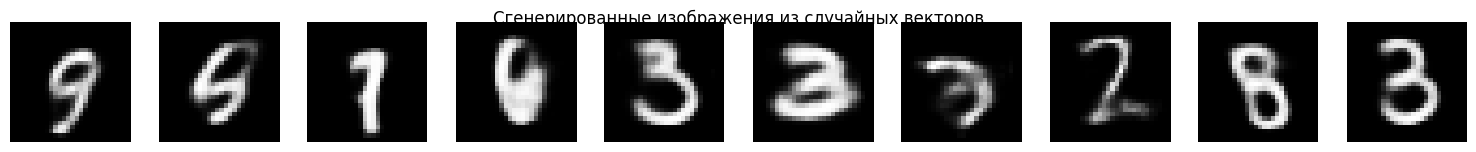

In [18]:
# Генерирую изображения из случайных векторов
z = np.array([np.random.normal(0, 1, 100) for i in range(10)])
z = torch.from_numpy(z).float().to(device)
output = autoencoder.decode(z)

# Визуализирую сгенерированные изображения
plt.figure(figsize=(15, 1.5))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(output[i].detach().cpu().squeeze(), cmap='gray')
    plt.axis('off')

plt.tight_layout()
plt.suptitle("Сгенерированные изображения из случайных векторов")
plt.show()

## 2.2. Latent Representation

Получаю латентные представления...
Применяю t-SNE для визуализации латентного пространства...


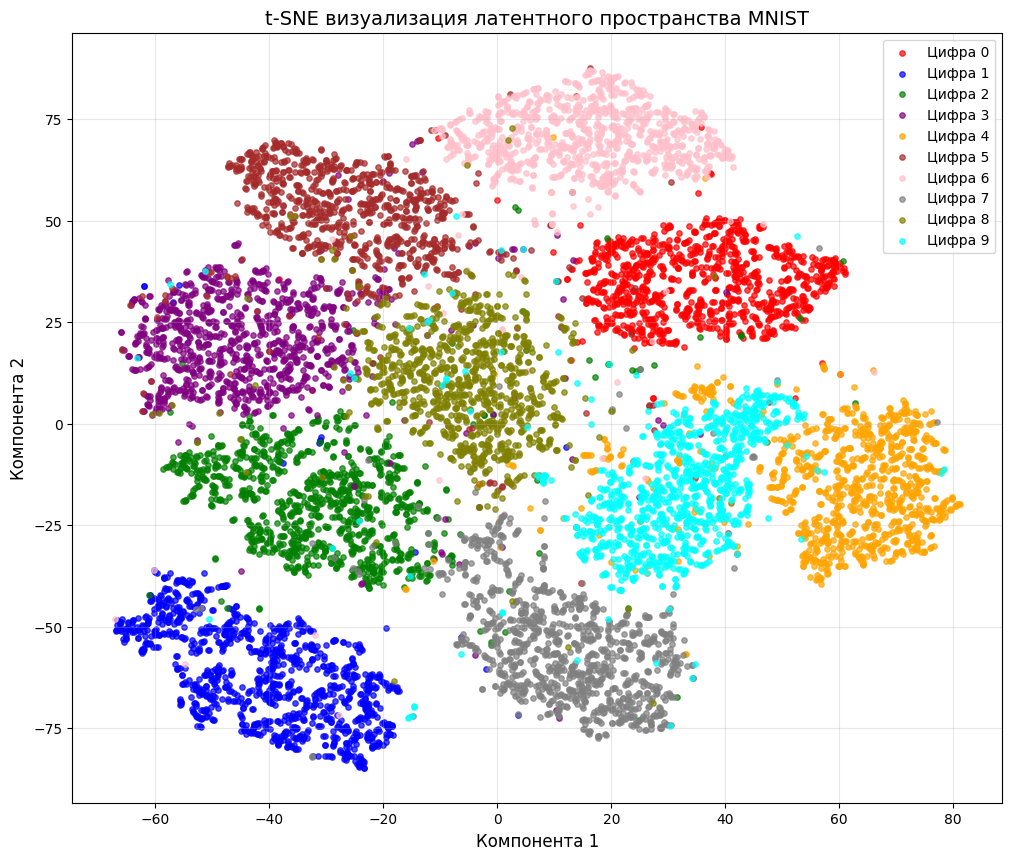

Визуализация завершена! Различные цвета соответствуют разным цифрам.


In [19]:
# Получу латентные представления картинок тестового датасета
print("Получаю латентные представления...")
autoencoder.eval()  # Переключу модель в режим оценки

# Соберу все латентные представления и метки классов
latent_vectors = []
labels = []

with torch.no_grad():
    for data, label in test_loader:
        data = data.to(device)
        # Получу mu (среднее) для каждого изображения
        mu, logsigma, _ = autoencoder(data)
        # Сохраню латентные векторы и метки
        latent_vectors.append(mu.cpu().numpy())
        labels.append(label.numpy())

# Объединю все батчи
latent_vectors = np.concatenate(latent_vectors, axis=0)
labels = np.concatenate(labels, axis=0)

# Использую t-SNE для сжатия до 2D (если размерность латентного пространства > 2)
print("Применяю t-SNE для визуализации латентного пространства...")
tsne = TSNE(n_components=2, random_state=42)
latent_2d = tsne.fit_transform(latent_vectors)

# Визуализирую полученные двумерные представления
plt.figure(figsize=(12, 10))

# Создам словарь с цветами для каждой цифры
colors = {
    0: 'red',
    1: 'blue',
    2: 'green',
    3: 'purple',
    4: 'orange',
    5: 'brown',
    6: 'pink',
    7: 'gray',
    8: 'olive',
    9: 'cyan'
}

# Создам scatter plot с разными цветами для каждой цифры
for digit in range(10):
    # Выберу точки, соответствующие текущей цифре
    idx = labels == digit
    plt.scatter(
        latent_2d[idx, 0], 
        latent_2d[idx, 1], 
        c=colors[digit],
        label=f'Цифра {digit}',
        alpha=0.7,
        s=15
    )

plt.title("t-SNE визуализация латентного пространства MNIST", fontsize=14)
plt.xlabel("Компонента 1", fontsize=12)
plt.ylabel("Компонента 2", fontsize=12)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.show()

print("Визуализация завершена! Различные цвета соответствуют разным цифрам.")

### Выводы:

* Четкое разделение цифр: каждая цифра формирует отдельный, хорошо выраженный кластер, что говорит о высоком качестве латентного представления

* Пространственная организация: кластеры распределены по всему пространству в виде своеобразного круга

* Локальные группировки: некоторые визуально похожие цифры расположены ближе друг к другу. Например,  4 и 9.

* Внутрикластерная структура: внутри кластеров точки расположены неравномерно, формируя подгруппы, что видимо отражает различные стили написания цифр

## 2.3. Conditional VAE

### Архитектура

In [20]:
# Задам архитектуру CVAE
class CVAE(nn.Module):
    def __init__(self):
        super(CVAE, self).__init__()
        
        self.latent_dim = 100  # размерность латентного пространства
        self.num_classes = 10  # количество классов MNIST
        
        # Энкодер (принимает изображение + one-hot вектор класса)
        # Изображение: 28x28=784 + one-hot(10) = 794 входных нейронов
        self.encoder_fc1 = nn.Linear(784 + self.num_classes, 400)
        self.encoder_fc2 = nn.Linear(400, 200)
        
        # Два "хвоста" для mu и logsigma
        self.fc_mu = nn.Linear(200, self.latent_dim)
        self.fc_logsigma = nn.Linear(200, self.latent_dim)
        
        # Декодер (принимает латентный вектор + one-hot вектор класса)
        # Размер входа: latent_dim + one-hot(10)
        self.decoder_fc1 = nn.Linear(self.latent_dim + self.num_classes, 200)
        self.decoder_fc2 = nn.Linear(200, 400)
        self.decoder_fc3 = nn.Linear(400, 784)
        
    def encode(self, x, class_num):
        # Преобразую изображение в вектор
        x = x.view(-1, 784)
        
        # Преобразую номер класса в one-hot вектор
        class_one_hot = torch.zeros(x.size(0), self.num_classes, device=x.device)
        class_one_hot.scatter_(1, class_num.unsqueeze(1), 1)
        
        # Конкатенирую изображение и one-hot вектор класса
        x_combined = torch.cat([x, class_one_hot], dim=1)
        
        # Прогоню через энкодер
        h1 = F.relu(self.encoder_fc1(x_combined))
        h2 = F.relu(self.encoder_fc2(h1))
        
        # Получу mu и logsigma
        mu = self.fc_mu(h2)
        logsigma = self.fc_logsigma(h2)
        
        return mu, logsigma, class_num
    
    def gaussian_sampler(self, mu, logsigma):
        if self.training:
            # Репараметризация: z = mu + eps * sigma
            std = torch.exp(0.5 * logsigma)
            eps = torch.randn_like(std)
            z = mu + eps * std
            return z
        else:
            # На инференсе возвращаю mu
            return mu
    
    def decode(self, z, class_num):
        # Проверю, что class_num на том же устройстве, что и z
        class_num = class_num.to(z.device)
        
        # Преобразую номер класса в one-hot вектор на том же устройстве
        batch_size = z.size(0)
        class_one_hot = torch.zeros(batch_size, self.num_classes, device=z.device)
        class_one_hot.scatter_(1, class_num.unsqueeze(1), 1)
        z_combined = torch.cat([z, class_one_hot], dim=1)
        
        # Прогоню через декодер
        h3 = F.relu(self.decoder_fc1(z_combined))
        h4 = F.relu(self.decoder_fc2(h3))
        reconstruction = torch.sigmoid(self.decoder_fc3(h4))
        
        # Восстанавлю форму изображения
        reconstruction = reconstruction.view(-1, 1, 28, 28)
        
        return reconstruction
    
    def forward(self, x, class_num):
        # Полный проход через автоэнкодер
        mu, logsigma, class_num = self.encode(x, class_num)
        z = self.gaussian_sampler(mu, logsigma)
        reconstruction = self.decode(z, class_num)
        
        return mu, logsigma, reconstruction

### Обучение CVAE на MNIST

Начинаю обучение CVAE...
Эпоха [1/30], Batch [100/1875], Loss: 196.3862, KL: 1.2945, Recon: 195.0917
Эпоха [1/30], Batch [200/1875], Loss: 196.5215, KL: 4.1673, Recon: 192.3542
Эпоха [1/30], Batch [300/1875], Loss: 180.4115, KL: 6.9184, Recon: 173.4931
Эпоха [1/30], Batch [400/1875], Loss: 175.1373, KL: 8.7388, Recon: 166.3985
Эпоха [1/30], Batch [500/1875], Loss: 156.2323, KL: 9.5084, Recon: 146.7240
Эпоха [1/30], Batch [600/1875], Loss: 157.4158, KL: 11.7363, Recon: 145.6795
Эпоха [1/30], Batch [700/1875], Loss: 144.1363, KL: 10.9645, Recon: 133.1718
Эпоха [1/30], Batch [800/1875], Loss: 153.9268, KL: 11.0445, Recon: 142.8824
Эпоха [1/30], Batch [900/1875], Loss: 144.8748, KL: 11.3109, Recon: 133.5638
Эпоха [1/30], Batch [1000/1875], Loss: 140.1347, KL: 11.2915, Recon: 128.8432
Эпоха [1/30], Batch [1100/1875], Loss: 131.6783, KL: 12.2975, Recon: 119.3807
Эпоха [1/30], Batch [1200/1875], Loss: 129.3228, KL: 12.2838, Recon: 117.0390
Эпоха [1/30], Batch [1300/1875], Loss: 140.2475, KL: 

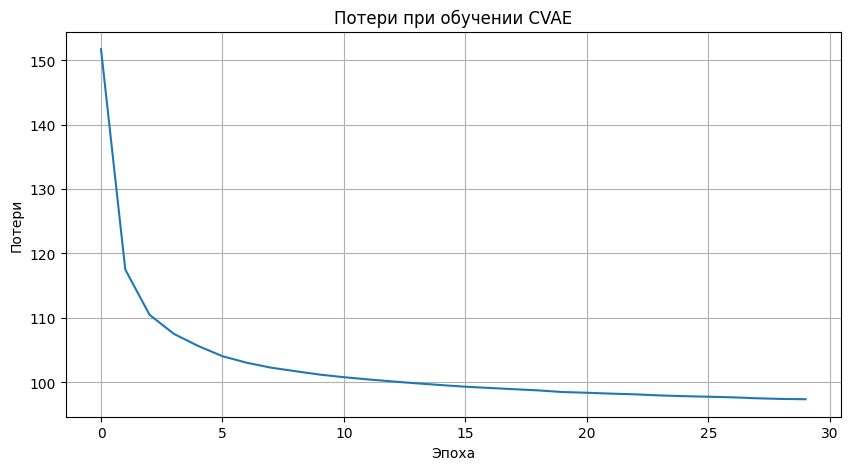

Обучение завершено!
Модель сохранена в файл 'cvae_mnist.pth'


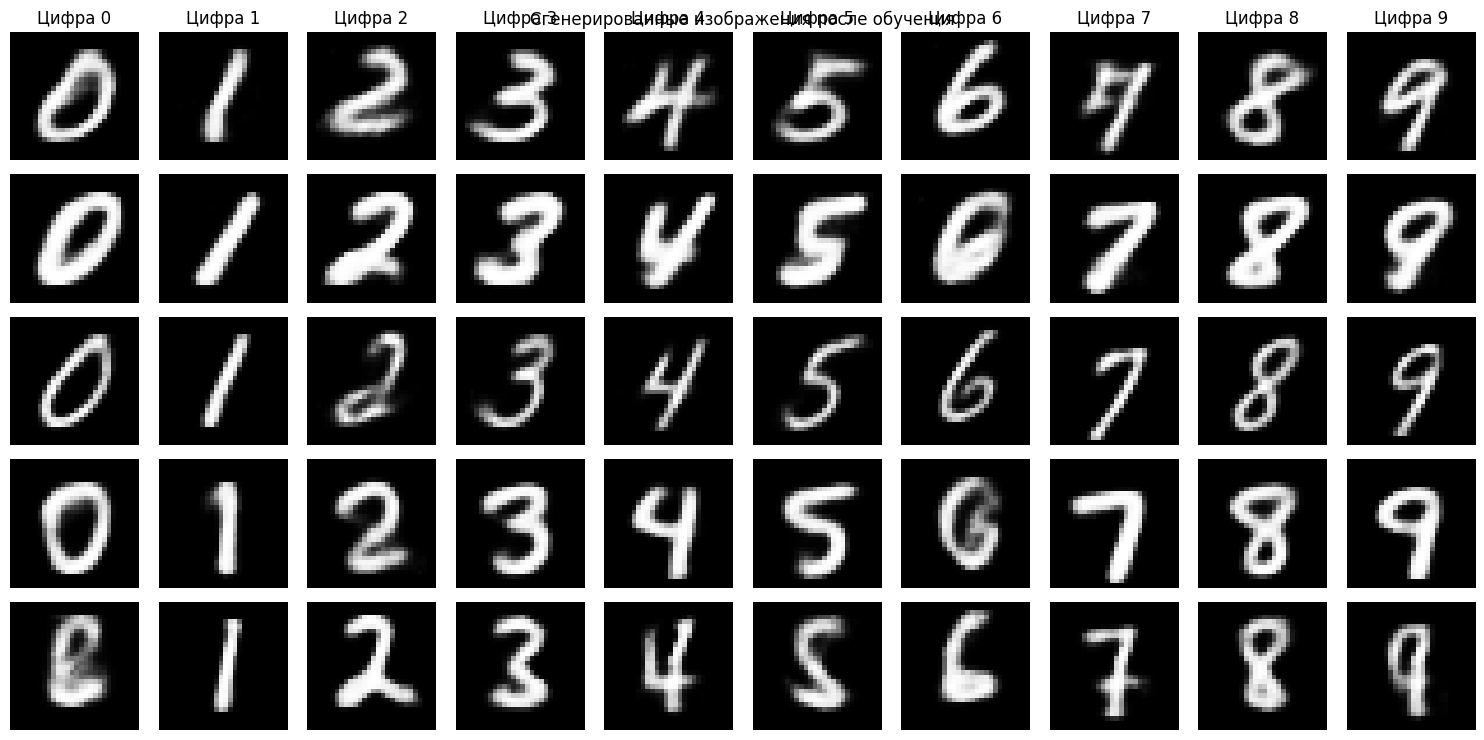

In [21]:
# Инициализирую CVAE и переносу на GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cvae = CVAE().to(device)

# Оптимизатор
optimizer = optim.Adam(cvae.parameters(), lr=0.001)

# Функция для визуализации реконструкций
def visualize_reconstruction(model, data_loader, epoch):
    model.eval()
    with torch.no_grad():
        # Беру первые 8 изображений с метками
        data, labels = next(iter(data_loader))
        data, labels = data[:8].to(device), labels[:8].to(device)
        
        # Получу реконструкции
        mu, logsigma, reconstructions = model(data, labels)
        
        # Визуализирую
        plt.figure(figsize=(16, 4))
        
        # Оригиналы
        for i in range(8):
            plt.subplot(2, 8, i+1)
            plt.imshow(data[i].cpu().squeeze().numpy(), cmap='gray')
            plt.title(f'Цифра {labels[i].item()}')
            plt.axis('off')
        
        # Реконструкции
        for i in range(8):
            plt.subplot(2, 8, i+8+1)
            plt.imshow(reconstructions[i].cpu().squeeze().numpy(), cmap='gray')
            plt.axis('off')
        
        plt.suptitle(f'Эпоха {epoch+1}')
        plt.tight_layout()
        plt.savefig(f'cvae_reconstruction_epoch_{epoch+1}.png')
        plt.close()

# Функция обучения CVAE
def train_cvae(num_epochs=30):
    train_losses = []
    
    for epoch in range(num_epochs):
        cvae.train()
        running_loss = 0.0
        
        for batch_idx, (data, labels) in enumerate(train_loader):
            # Перемещу данные на устройство
            data, labels = data.to(device), labels.to(device)
            
            # Очищу градиенты
            optimizer.zero_grad()
            
            # Прямой проход
            mu, logsigma, reconstructions = cvae(data, labels)
            
            # Вычислю потери: KL дивергенция + reconstruction loss
            kl_div = KL_divergence(mu, logsigma)
            recon_loss = log_likelihood(data, reconstructions)
            loss = kl_div + recon_loss
            
            # Обратное распространение ошибки
            loss.backward()
            
            # Оптимизация весов
            optimizer.step()
            
            running_loss += loss.item()
            
            if (batch_idx + 1) % 100 == 0:
                print(f'Эпоха [{epoch+1}/{num_epochs}], Batch [{batch_idx+1}/{len(train_loader)}], '
                      f'Loss: {loss.item():.4f}, KL: {kl_div.item():.4f}, Recon: {recon_loss.item():.4f}')
        
        # Средние потери за эпоху
        epoch_loss = running_loss / len(train_loader)
        train_losses.append(epoch_loss)
        
        print(f'Эпоха {epoch+1}/{num_epochs}, Средние потери: {epoch_loss:.4f}')
        
        # Визуализирую реконструкции каждые 5 эпох
        if (epoch + 1) % 10 == 0 or epoch == 0:
            visualize_reconstruction(cvae, test_loader, epoch)
    
    # Сохраняем обученную модель
    torch.save(cvae.state_dict(), 'cvae_mnist.pth')
    
    # График потерь
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses)
    plt.title('Потери при обучении CVAE')
    plt.xlabel('Эпоха')
    plt.ylabel('Потери')
    plt.grid(True)
    plt.savefig('cvae_training_loss.png')
    plt.show()
    
    return train_losses

# Запускаем обучение
print("Начинаю обучение CVAE...")
train_losses = train_cvae(num_epochs=30)
print("Обучение завершено!")
print(f"Модель сохранена в файл 'cvae_mnist.pth'")

# Проверяем, что модель работает - генерируем изображения
cvae.eval()
with torch.no_grad():
    # Фиксированные латентные векторы для всех цифр
    num_samples = 5
    z = torch.randn(num_samples, cvae.latent_dim).to(device)
    
    plt.figure(figsize=(15, num_samples * 1.5))
    
    # Генерируем по одному изображению для каждой цифры
    for digit in range(10):
        digit_tensor = torch.tensor([digit] * num_samples).to(device)
        generated_images = cvae.decode(z, digit_tensor)
        
        for i in range(num_samples):
            plt.subplot(num_samples, 10, i * 10 + digit + 1)
            plt.imshow(generated_images[i].cpu().squeeze().numpy(), cmap='gray')
            if i == 0:
                plt.title(f'Цифра {digit}')
            plt.axis('off')
    
    plt.tight_layout()
    plt.suptitle("Сгенерированные изображения после обучения")
    plt.savefig('cvae_generated_digits.png')
    plt.show()

### Sampling

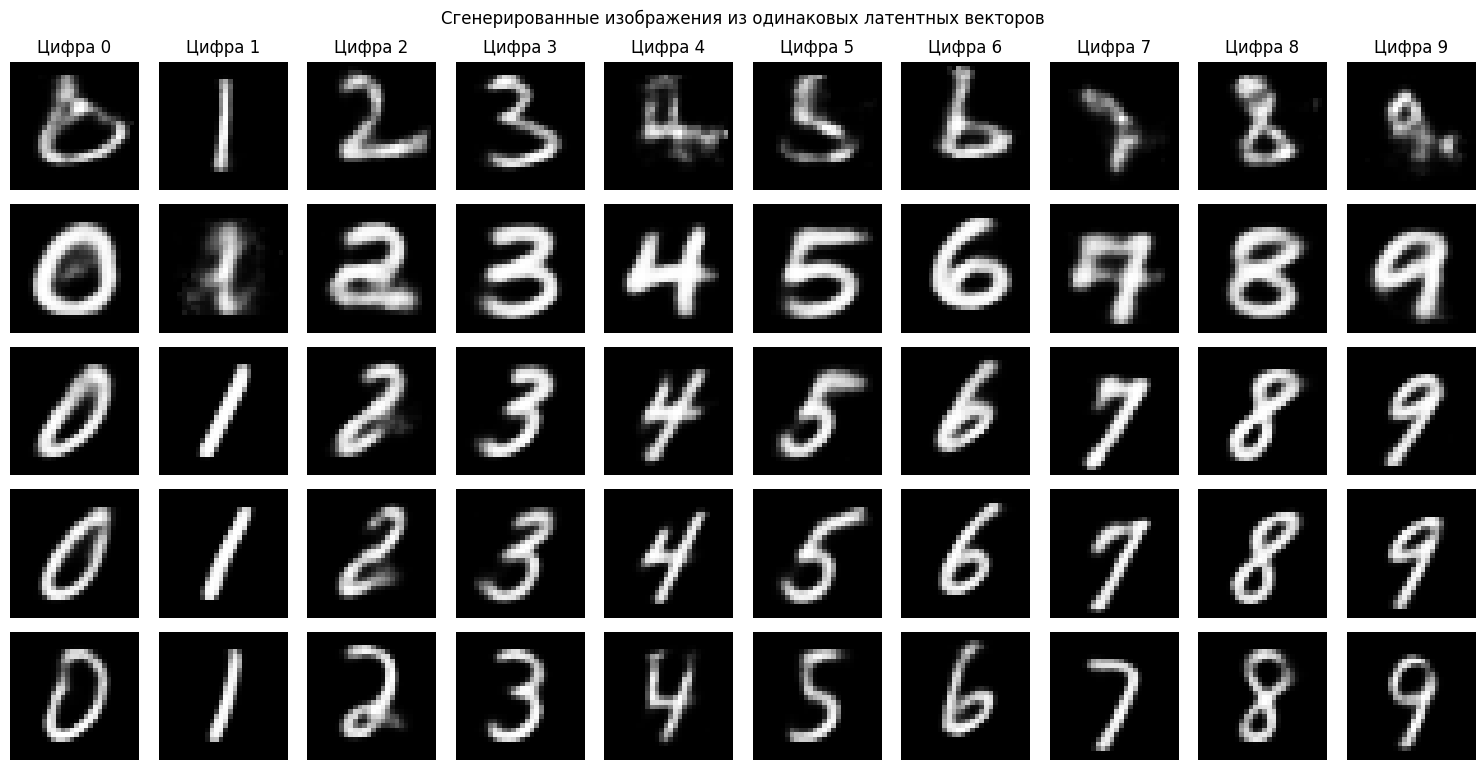

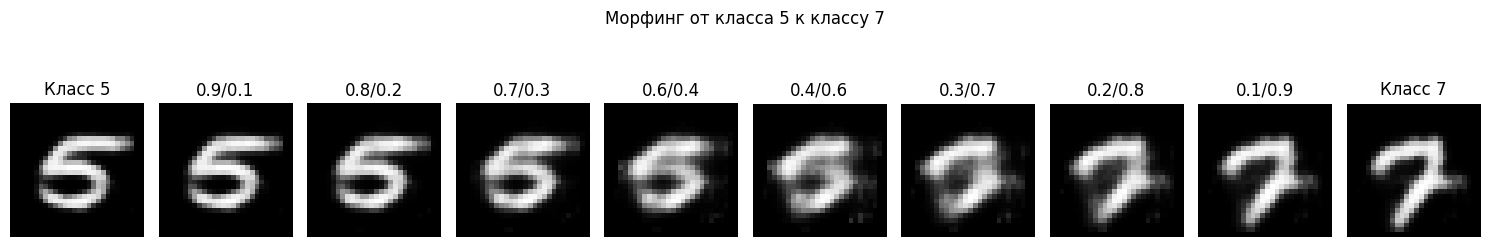

In [22]:
# Инициализирую модель CVAE
cvae = CVAE()
# Переносу модель на GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cvae.load_state_dict(torch.load('cvae_mnist.pth'))
cvae = cvae.to(device)
cvae.eval()

# Функция для визуализации нескольких сгенерированных изображений разных классов
def visualize_cvae_generation(num_samples=5):
    # Выберу фиксированные латентные векторы для сравнения разных цифр
    z = torch.randn(num_samples, cvae.latent_dim).to(device)
    
    # Создам сетку для визуализации (10 классов × num_samples)
    plt.figure(figsize=(15, num_samples * 1.5))
    
    # Сгенерирую изображения для каждого класса, используя одни и те же латентные векторы
    for digit in range(10):  # для каждой цифры от 0 до 9
        digit_tensor = torch.tensor([digit] * num_samples).to(device)
        
        with torch.no_grad():
            generated_images = cvae.decode(z, digit_tensor)
        
        # Отображу сгенерированные изображения
        for i in range(num_samples):
            plt.subplot(num_samples, 10, i * 10 + digit + 1)
            plt.imshow(generated_images[i].cpu().squeeze().numpy(), cmap='gray')
            if i == 0:
                plt.title(f'Цифра {digit}')
            plt.axis('off')
    
    plt.tight_layout()
    plt.suptitle("Сгенерированные изображения из одинаковых латентных векторов", y=1.02)
    plt.show()

# Функция для визуализации перехода между классами
def visualize_class_morphing(start_class=5, end_class=7, steps=10):    
    # Создам один латентный вектор
    z = torch.randn(1, cvae.latent_dim).to(device)
    
    plt.figure(figsize=(15, 3))
    
    # Визуализирую исходный класс
    with torch.no_grad():
        start_digit = torch.tensor([start_class]).to(device)
        start_image = cvae.decode(z, start_digit)
    
    plt.subplot(1, steps + 2, 1)
    plt.imshow(start_image.cpu().squeeze().numpy(), cmap='gray')
    plt.title(f'Класс {start_class}')
    plt.axis('off')
    
    # Сгенерирую плавный переход между классами
    for i in range(steps):
        # Интерполируем one-hot векторы
        alpha = (i + 1) / (steps + 1)
        
        # Создам смешанный one-hot вектор
        mixed_one_hot = torch.zeros(1, cvae.num_classes).to(device)
        mixed_one_hot[0, start_class] = 1.0 - alpha
        mixed_one_hot[0, end_class] = alpha
        
        # Сгенерирую изображение
        with torch.no_grad():
            # Декодирую через ручное создание смешанного класса
            # Сначала объединю латентный вектор с mixed_one_hot
            z_combined = torch.cat([z, mixed_one_hot], dim=1)
            h3 = F.relu(cvae.decoder_fc1(z_combined))
            h4 = F.relu(cvae.decoder_fc2(h3))
            mixed_image = torch.sigmoid(cvae.decoder_fc3(h4)).view(-1, 1, 28, 28)
        
        plt.subplot(1, steps + 2, i + 2)
        plt.imshow(mixed_image.cpu().squeeze().numpy(), cmap='gray')
        plt.title(f'{1.0-alpha:.1f}/{alpha:.1f}')
        plt.axis('off')
    
    # Визуализирую конечный класс
    with torch.no_grad():
        end_digit = torch.tensor([end_class]).to(device)
        end_image = cvae.decode(z, end_digit)
    
    plt.subplot(1, steps + 2, steps + 2)
    plt.imshow(end_image.cpu().squeeze().numpy(), cmap='gray')
    plt.title(f'Класс {end_class}')
    plt.axis('off')
    
    plt.suptitle(f'Морфинг от класса {start_class} к классу {end_class}')
    plt.tight_layout()
    plt.show()

# Запущу визуализацию
visualize_cvae_generation(num_samples=5)
visualize_class_morphing(start_class=5, end_class=7, steps=8)

### Latent Representations

Применяю t-SNE для визуализации латентного пространства...


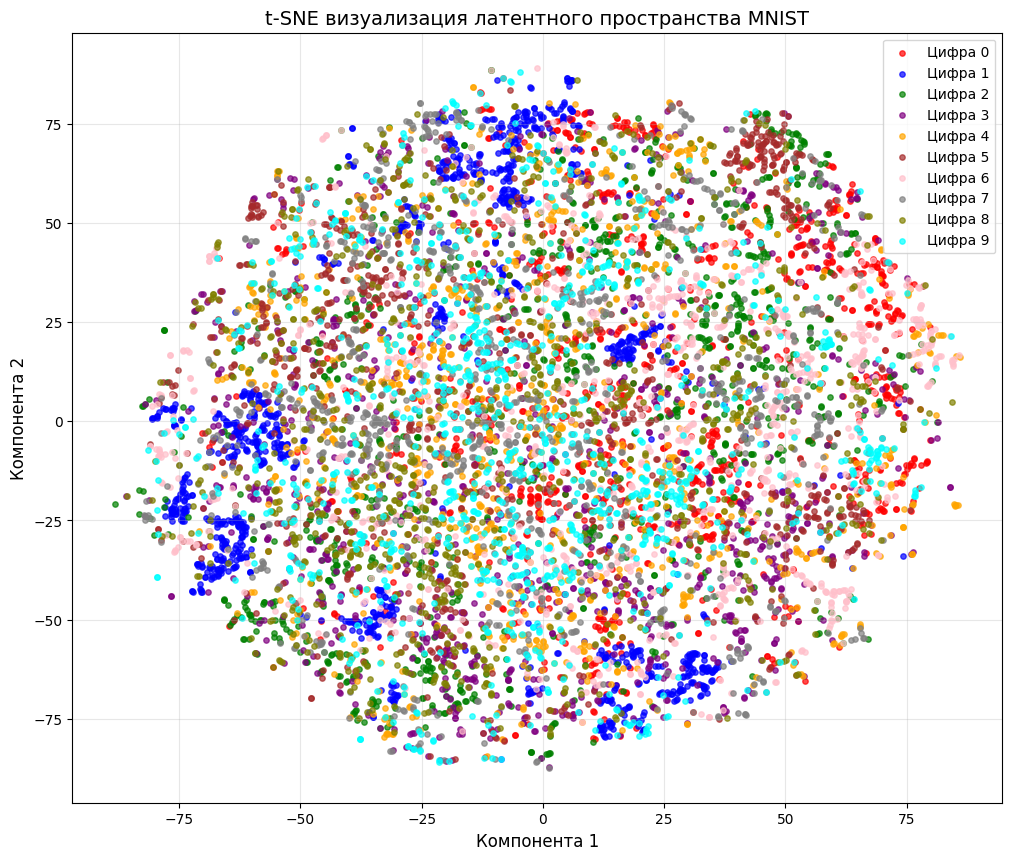

Визуализация завершена! Различные цвета соответствуют разным цифрам.


In [23]:
# Переключу модель в режим оценки
cvae.eval()

latent_vectors = []
labels = []

with torch.no_grad():
    for data, label in test_loader:
        data = data.to(device)
        label = label.to(device)
        # Получу mu (среднее) для каждого изображения
        mu, logsigma, _ = cvae(data, label)
        latent_vectors.append(mu.cpu().numpy())
        labels.append(label.cpu().numpy())

# Объединю все батчи
latent_vectors = np.concatenate(latent_vectors, axis=0)
labels = np.concatenate(labels, axis=0)

# Применяю t-SNE для сжатия до 2D
print("Применяю t-SNE для визуализации латентного пространства...")
tsne = TSNE(n_components=2, random_state=42)
latent_2d = tsne.fit_transform(latent_vectors)

# Визуализирую
plt.figure(figsize=(12, 10))

colors = {
    0: 'red',
    1: 'blue',
    2: 'green',
    3: 'purple',
    4: 'orange',
    5: 'brown',
    6: 'pink',
    7: 'gray',
    8: 'olive',
    9: 'cyan'
}

for digit in range(10):
    idx = labels == digit
    plt.scatter(
        latent_2d[idx, 0], 
        latent_2d[idx, 1], 
        c=colors[digit],
        label=f'Цифра {digit}',
        alpha=0.7,
        s=15
    )

plt.title("t-SNE визуализация латентного пространства MNIST", fontsize=14)
plt.xlabel("Компонента 1", fontsize=12)
plt.ylabel("Компонента 2", fontsize=12)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.show()

print("Визуализация завершена! Различные цвета соответствуют разным цифрам.")

### Выводы:

Точки разных цветов хаотично перемешаны, отсутствуют явные кластеры для разных цифр, латентное пространство выглядит как единое "облако" без структуры.

Почему так? Разницу с VAE можно объяснить из-за принципиальных отличий в архитектуре моделей.

В CVAE информация о классе подается в модель отдельно как условие, латентному пространству не нужно кодировать класс цифры, только её стиль/вариации.

Поэтому одна и та же область латентного пространства может использоваться для разных цифр, так как выбор цифры контролируется условием, а не положением в латентном пространстве.

В CVAE латентное пространство лучше отражает вариативность внутри классов (например, различные стили написания), а не между классами. Именно поэтому при генерации изображений мы можем:

* 1. использовать один и тот же латентный вектор

* 2. получать разные цифры, изменяя только условие

* 3. создавать более четкие изображения при малой размерности латентного пространства.

Перемешанные точки в визуализации CVAE - признак того, что модель успешно отделила информацию о классе от латентного представления, что и является целью вариационного автоэнкодера.